# Analyse et Visualisation des Vulnérabilités (CVE)

Ce notebook a pour objectif d'exploiter les données collectées depuis les flux de l'ANSSI (et enrichies via MITRE/FIRST) pour produire des indicateurs décisionnels.

**Objectifs de l'analyse :**
1. Comprendre la répartition de la gravité des menaces (CVSS).
2. Identifier les types de failles techniques les plus fréquents (CWE).
3. Comparer la gravité théorique (CVSS) à la probabilité réelle d'exploitation (EPSS).
4. Cibler les éditeurs et produits nécessitant une vigilance accrue.
5. Filtrer les alertes critiques pour le module de notification.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration du style visuel
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Palette de couleurs (Rouge, Orange, Gris pour la cybersécurité)
CYBER_PALETTE = sns.color_palette("rocket", as_cmap=False)

print("[INFO] Bibliothèques chargées et configuration appliquée.")

[INFO] Bibliothèques chargées et configuration appliquée.


### Chargement du Dataset
Nous importons le fichier CSV généré par le script de collecte.
Si le fichier n'existe pas (première exécution sans collecte), un jeu de données factice est généré pour permettre de tester les graphiques.

In [5]:
# Nom du fichier CSV généré par le script précédent
csv_file = "anssi_cve_dataframe.csv"

try:
    df = pd.read_csv(csv_file)
    print(f"[INFO] Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
except FileNotFoundError:
    print(f"[ERREUR] Le fichier '{csv_file}' est introuvable.")
    print("[WARN] Génération de données factices pour la démonstration...")
    
    # Génération de données de test si le fichier manque
    data = {
        'Identifiant CVE': [f'CVE-2024-{1000+i}' for i in range(100)],
        'Score CVSS': np.random.uniform(2, 10, 100),
        'Score EPSS': np.random.exponential(0.1, 100), # Distribution exponentielle typique pour EPSS
        'Type CWE': np.random.choice(['CWE-79', 'CWE-89', 'CWE-20', 'CWE-787', 'Autres'], 100),
        'Éditeur/Vendor': np.random.choice(['Microsoft', 'Cisco', 'Adobe', 'Google', 'Linux'], 100),
        'Produit': ['Produit Générique'] * 100,
        'Date de publication': pd.date_range(start='2024-01-01', periods=100),
        'Type de bulletin': np.random.choice(['Alerte', 'Avis'], 100)
    }
    df = pd.DataFrame(data)

# Aperçu des premières lignes
df.head()

[INFO] Données chargées : 2648 lignes, 14 colonnes.


,ID ANSSI,Titre du bulletin (ANSSI),Type de bulletin,Date de publication,Identifiant CVE,Score CVSS,Type CWE,Score EPSS,Lien du bulletin (ANSSI),Description,Editeur/Vendor,Produit,Versions affectees,Severity
0,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC (16 ...,Alerte,"Fri, 16 Dec 2022 00:00:00 +0000",CVE-2022-40259,8.3,CWE-798,0.003020000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,MegaRAC Default Credentials Vulnerability,AMI,MegaRAC SPx12,0,Haute
1,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC (16 ...,Alerte,"Fri, 16 Dec 2022 00:00:00 +0000",CVE-2022-40259,8.3,CWE-798,0.003020000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,MegaRAC Default Credentials Vulnerability,AMI,MegaRAC SPx13,0,Haute
2,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC (16 ...,Alerte,"Fri, 16 Dec 2022 00:00:00 +0000",CVE-2022-40242,7.5,CWE-798,0.001370000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,MegaRAC Default Credentials Vulnerability,AMI,MegaRAC SPx12,0,Haute
3,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC (16 ...,Alerte,"Fri, 16 Dec 2022 00:00:00 +0000",CVE-2022-40242,7.5,CWE-798,0.001370000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,MegaRAC Default Credentials Vulnerability,AMI,MegaRAC SPx13,0,Haute
4,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC (16 ...,Alerte,"Fri, 16 Dec 2022 00:00:00 +0000",CVE-2022-2827,7.5,CWE-200,0.161080000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,AMI MegaRAC User Enumeration Vulnerability,AMI,MegaRAC SPx12,0,Haute


### Nettoyage et Préparation des Données (Data Cleaning)
Les données brutes contiennent souvent des valeurs manquantes ou des types incorrects (ex: nombres stockés en texte).

**Actions effectuées :**
1. Conversion des colonnes CVSS et EPSS en numérique (gestion des erreurs).
2. Conversion de la date au format Datetime.
3. Remplissage des valeurs manquantes (NaN) par "Inconnu".
4. Création d'une colonne catégorielle "Gravité" basée sur le score CVSS.

In [6]:
# 1. Conversion des scores en numérique (les "Non disponible" deviennent NaN)
df['Score CVSS'] = pd.to_numeric(df['Score CVSS'], errors='coerce')
df['Score EPSS'] = pd.to_numeric(df['Score EPSS'], errors='coerce')

# 2. Conversion des dates
df['Date de publication'] = pd.to_datetime(df['Date de publication'], utc=True, errors='coerce')

# 3. Remplissage des valeurs manquantes pour les catégories
df['Type de bulletin'] = df['Type de bulletin'].fillna("Inconnu")
df['Editeur/Vendor'] = df['Editeur/Vendor'].fillna("Inconnu")


# Vérification des types après nettoyage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   ID ANSSI                   2648 non-null   object             
 1   Titre du bulletin (ANSSI)  2648 non-null   object             
 2   Type de bulletin           2648 non-null   object             
 3   Date de publication        2648 non-null   datetime64[ns, UTC]
 4   Identifiant CVE            2648 non-null   object             
 5   Score CVSS                 405 non-null    float64            
 6   Type CWE                   2648 non-null   object             
 7   Score EPSS                 2636 non-null   float64            
 8   Lien du bulletin (ANSSI)   2648 non-null   object             
 9   Description                2648 non-null   object             
 10  Editeur/Vendor             2648 non-null   object             
 11  Prod

### Analyse de la Gravité (CVSS)
Le score CVSS (Common Vulnerability Scoring System) définit la sévérité théorique d'une faille.
Nous observons ici la distribution des scores pour voir si nous sommes face à une majorité de failles critiques ou mineures.

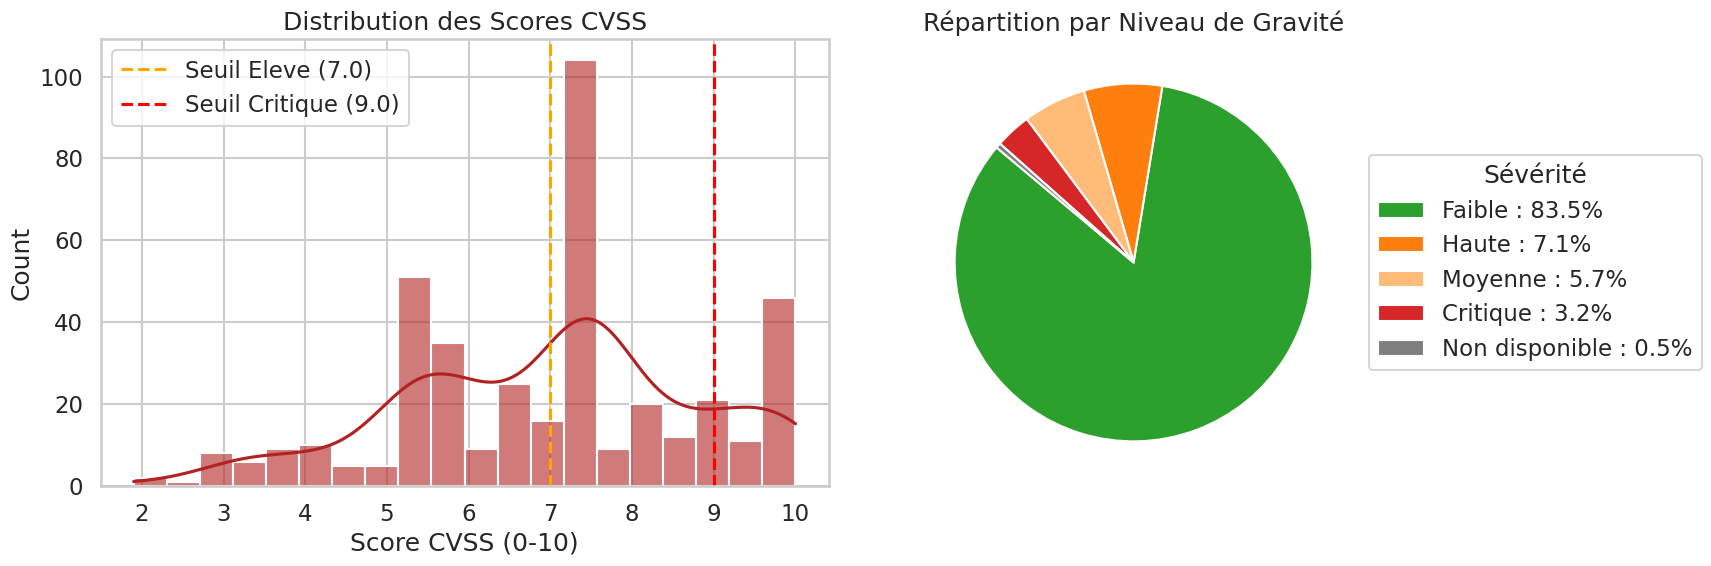

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Création d'une grille de 2 graphiques
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# --- Graphique 1 : Histogramme  ---
sns.histplot(data=df, x=df["Score CVSS"], kde=True, bins=20, color="firebrick", alpha=0.6, ax=ax[0])
ax[0].set_title("Distribution des Scores CVSS")
ax[0].set_xlabel("Score CVSS (0-10)")
ax[0].axvline(x=7.0, color='orange', linestyle='--', label='Seuil Eleve (7.0)')
ax[0].axvline(x=9.0, color='red', linestyle='--', label='Seuil Critique (9.0)')
ax[0].legend()

# --- Graphique 2 : Camembert ---
gravite_counts = df['Severity'].value_counts()
colors_map = {
    'Critique': '#d62728', 
    'Haute': '#ff7f0e',   
    'Moyenne': '#ffbb78',  
    'Faible': '#2ca02c',   
    'Non disponible': '#7f7f7f'
}

# 1. Calculer le total pour faire les pourcentages manuellement
total = gravite_counts.sum()

# 2. Créer une liste de labels formatés pour la légende : "Catégorie : XX.X%"
legend_labels = [f"{name} : {(value/total)*100:.1f}%" for name, value in gravite_counts.items()]

# 3. Générer le Pie Chart 

wedges, texts = ax[1].pie(
    gravite_counts,
    labels=None, 
    startangle=140, 
    colors=[colors_map.get(x, '#999') for x in gravite_counts.index]
)

# 4. Passer les labels personnalisés à la légende
ax[1].legend(
    wedges, 
    legend_labels, # <--- C'est ici qu'on met les %
    title="Sévérité", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax[1].set_title("Répartition par Niveau de Gravité")

plt.tight_layout()
plt.show()

### Analyse Technique (CWE)
Le CWE (Common Weakness Enumeration) catégorise le type de faille (ex: Injection SQL, Buffer Overflow).
Ce graphique montre les 10 types de vulnérabilités les plus fréquents dans le jeu de données.

/tmp/ipykernel_43335/44844788.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cwe_final.values, y=cwe_final.index, palette="viridis")


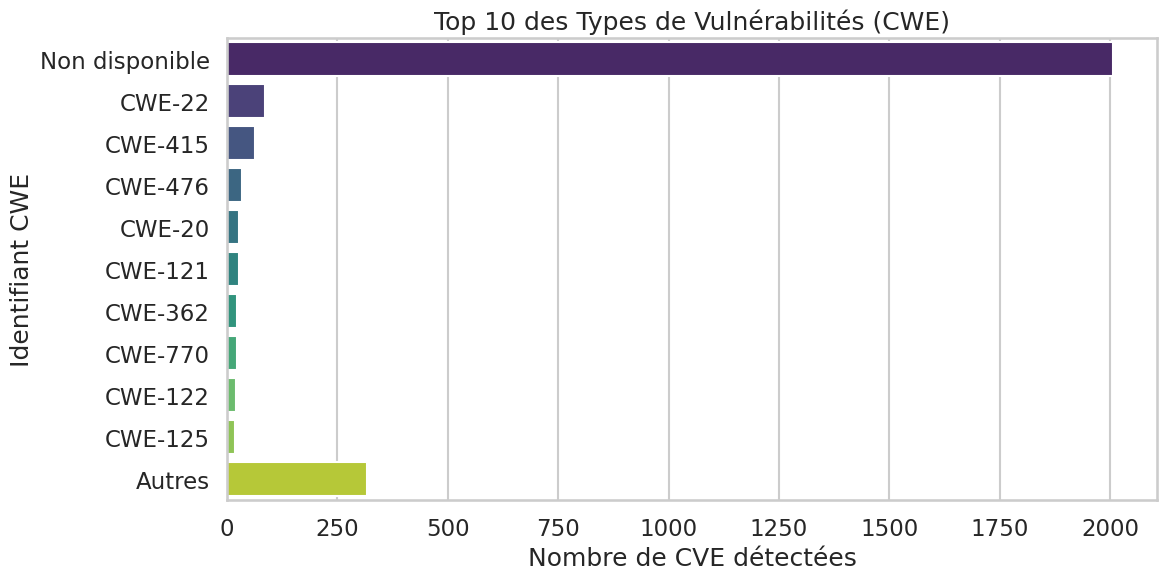

In [8]:
plt.figure(figsize=(12, 6))

# On garde le top 10 des CWE, on regroupe le reste en "Autres" pour la lisibilité
top_n = 10
cwe_counts = df['Type CWE'].value_counts()

if len(cwe_counts) > top_n:
    top_cwe = cwe_counts[:top_n]
    others = pd.Series([cwe_counts[top_n:].sum()], index=['Autres'])
    cwe_final = pd.concat([top_cwe, others])
else:
    cwe_final = cwe_counts

sns.barplot(x=cwe_final.values, y=cwe_final.index, palette="viridis")
plt.title(f"Top {top_n} des Types de Vulnérabilités (CWE)")
plt.xlabel("Nombre de CVE détectées")
plt.ylabel("Identifiant CWE")
plt.show()

### CVSS vs EPSS : Théorie vs Réalité
C'est l'analyse la plus importante pour la priorisation.
* **Axe X (CVSS)** : La gravité technique.
* **Axe Y (EPSS)** : La probabilité que cette faille soit exploitée par des pirates dans les 30 prochains jours.
* **Taille du point** : Proportionnelle au score EPSS.

**Interprétation :** Les points en haut à droite (CVSS élevé + EPSS élevé) sont les urgences absolues.

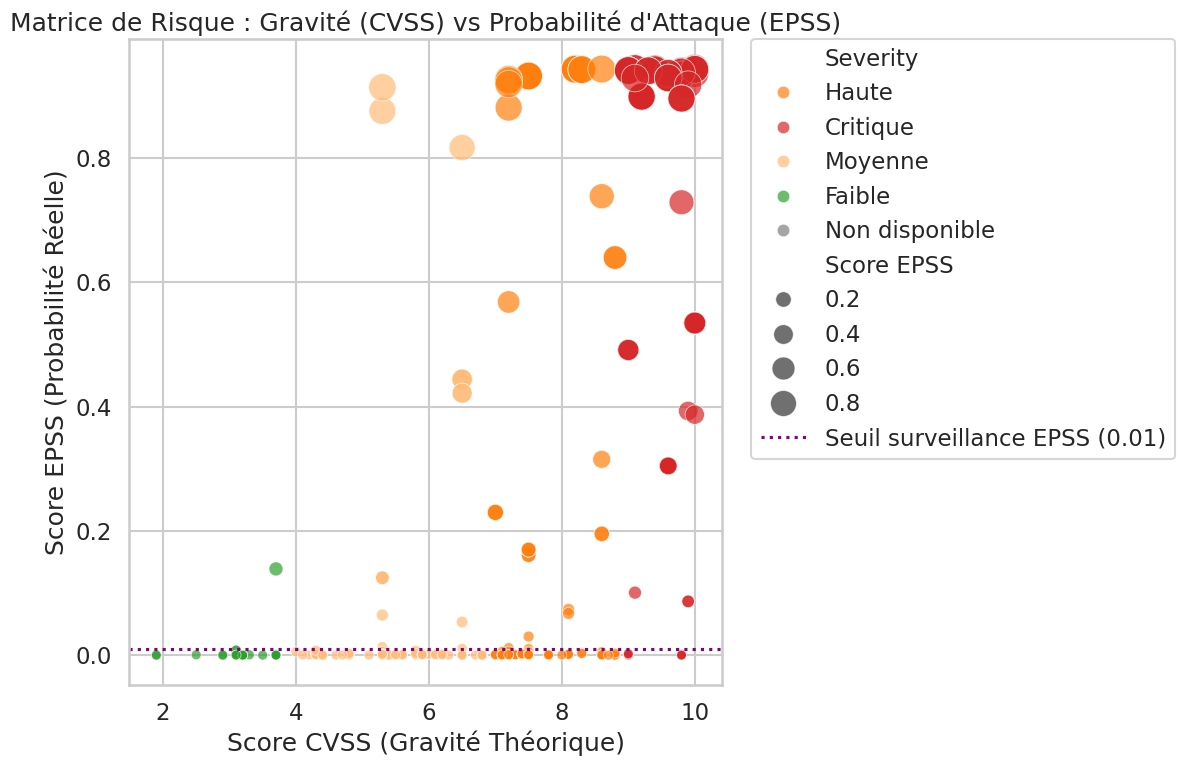

Matrice de corrélation entre les scores :
            Score CVSS  Score EPSS
Score CVSS     1.00000     0.55237
Score EPSS     0.55237     1.00000


In [9]:
plt.figure(figsize=(12, 8))

# Scatter plot
sns.scatterplot(
    data=df, 
    x="Score CVSS", 
    y="Score EPSS", 
    hue="Severity", 
    size="Score EPSS", 
    sizes=(50, 400), # Taille des bulles
    palette=colors_map,
    alpha=0.7
)

plt.title("Matrice de Risque : Gravité (CVSS) vs Probabilité d'Attaque (EPSS)")
plt.xlabel("Score CVSS (Gravité Théorique)")
plt.ylabel("Score EPSS (Probabilité Réelle)")

# Ligne de seuil critique pour l'EPSS (exemple arbitraire à 1% ou 10%)
seuil_epss = 0.01 # 1%
plt.axhline(y=seuil_epss, color='purple', linestyle=':', label=f'Seuil surveillance EPSS ({seuil_epss})')

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

# Affichage de la matrice de corrélation
print("Matrice de corrélation entre les scores :")
print(df[['Score CVSS', 'Score EPSS']].corr())

### Analyse par Éditeur
Quels sont les éditeurs logiciels les plus touchés ?
Nous affichons ici la dispersion des scores CVSS pour les 10 principaux éditeurs via un diagramme en boîte (Boxplot).

/tmp/ipykernel_43335/3335965420.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


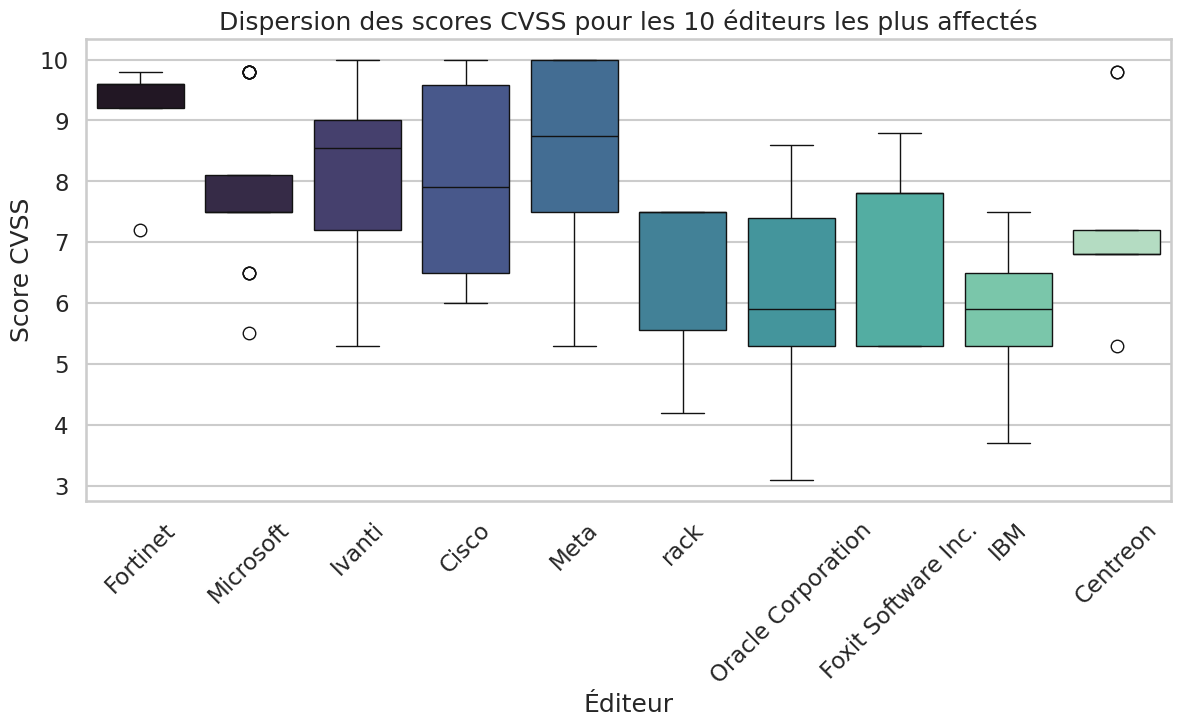

In [10]:
# Identification du Top 10 Éditeurs
# Conversion du CVSS en numérique + suppression des valeurs invalides
df_cvss = df.copy()
df_cvss["Score CVSS"] = pd.to_numeric(df_cvss["Score CVSS"], errors="coerce")
df_cvss = df_cvss.dropna(subset=["Score CVSS"])

# Top 10 éditeurs avec CVSS valides
top_vendors = df_cvss["Editeur/Vendor"].value_counts().head(10).index
df_top_vendors = df_cvss[df_cvss["Editeur/Vendor"].isin(top_vendors)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top_vendors,
    x="Editeur/Vendor",
    y="Score CVSS",
    palette="mako"
)
plt.xticks(rotation=45)
plt.title("Dispersion des scores CVSS pour les 10 éditeurs les plus affectés")
plt.xlabel("Éditeur")
plt.ylabel("Score CVSS")
plt.show()


### Dynamique Temporelle
Visualisation de l'arrivée des vulnérabilités dans le temps (basée sur la date de publication du bulletin ANSSI).
La courbe montre le cumul des CVE détectées. Une pente raide indique une période d'activité intense.

/tmp/ipykernel_43335/1808438818.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_cumul = df_time.resample('Y').size().cumsum()  # 'W' pour semaine


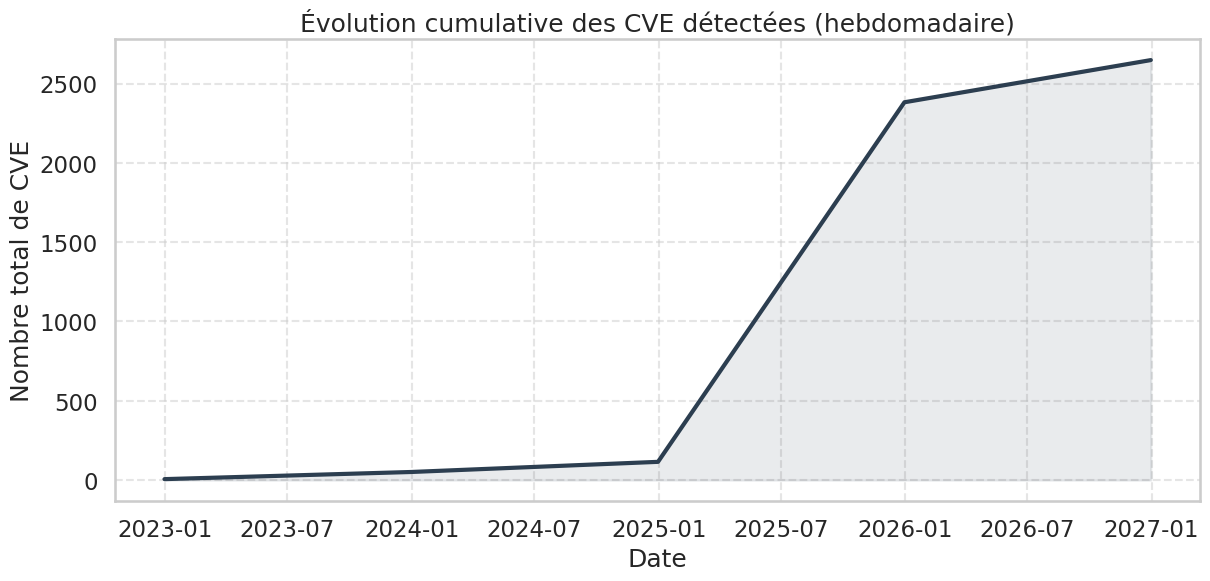

In [11]:
plt.figure(figsize=(14, 6))

# Tri par date et resampling par semaine
df_time = df.set_index('Date de publication').sort_index()
df_cumul = df_time.resample('Y').size().cumsum()  # 'W' pour semaine

sns.lineplot(data=df_cumul, linewidth=3, color="#2c3e50")
plt.fill_between(df_cumul.index, df_cumul.values, color="#2c3e50", alpha=0.1)

plt.title("Évolution cumulative des CVE détectées (hebdomadaire)")
plt.xlabel("Date")
plt.ylabel("Nombre total de CVE")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Synthèse pour le Module d'Alerte
Cette dernière étape isole les vulnérabilités qui nécessitent une action immédiate.
Critères retenus pour l'exemple :
* **CVSS >= 9.0** (Critique)
* **ET Score EPSS > 0.01** (Probabilité d'attaque significative)

Ces données constituent l'entrée du module d'envoi d'emails/notifications.

In [12]:
# Définition des seuils
SEUIL_CVSS = 9.0
SEUIL_EPSS = 0.01 # 1%

# Filtrage
must_fix = df[ (df['Score CVSS'] >= SEUIL_CVSS) & (df['Score EPSS'] > SEUIL_EPSS) ]
cve_critiques = df[df['Score CVSS'] >= SEUIL_CVSS]

print("="*60)
print("[RESULTAT] SYNTHESE DE L'ANALYSE")
print("="*60)
print(f"Total vulnérabilités analysées : {len(df)}")
print(f"Vulnérabilités CRITIQUES (CVSS >= {SEUIL_CVSS}) : {len(cve_critiques)}")
print(f"Vulnérabilités PRIORITAIRES (CVSS >= {SEUIL_CVSS} + EPSS > {SEUIL_EPSS}) : {len(must_fix)}")

print("\n[INFO] Top 5 des vulnérabilités à traiter en priorité :")
if not must_fix.empty:
    display(must_fix[['Identifiant CVE', 'Score CVSS', 'Score EPSS', 'Editeur/Vendor', 'Produit']].sort_values(by='Score EPSS', ascending=False).head(5))
else:
    print("Aucune vulnérabilité ne correspond aux critères stricts combinés.")

[RESULTAT] SYNTHESE DE L'ANALYSE
Total vulnérabilités analysées : 2648
Vulnérabilités CRITIQUES (CVSS >= 9.0) : 73
Vulnérabilités PRIORITAIRES (CVSS >= 9.0 + EPSS > 0.01) : 67

[INFO] Top 5 des vulnérabilités à traiter en priorité :


,Identifiant CVE,Score CVSS,Score EPSS,Editeur/Vendor,Produit
39,CVE-2023-35078,10.0,0.94482,Ivanti,Endpoint Manager Mobile
37,CVE-2023-35082,10.0,0.94423,Ivanti,EPMM
58,CVE-2024-21887,9.1,0.94412,Ivanti,IPS
57,CVE-2024-21887,9.1,0.94412,Ivanti,ICS
48,CVE-2023-4966,9.4,0.94348,Citrix,NetScaler ADC


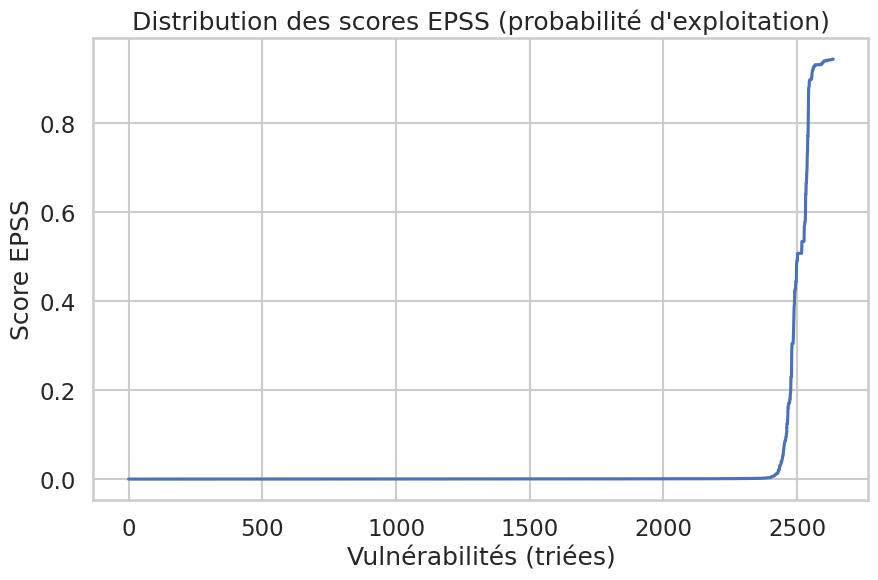

In [13]:
# Nettoyage EPSS
df_epss = df.copy()
df_epss["Score EPSS"] = pd.to_numeric(df_epss["Score EPSS"], errors="coerce")
df_epss = df_epss.dropna(subset=["Score EPSS"])

df_epss_sorted = df_epss.sort_values("Score EPSS")

plt.figure(figsize=(10, 6))
plt.plot(df_epss_sorted["Score EPSS"].values)
plt.title("Distribution des scores EPSS (probabilité d'exploitation)")
plt.xlabel("Vulnérabilités (triées)")
plt.ylabel("Score EPSS")
plt.show()


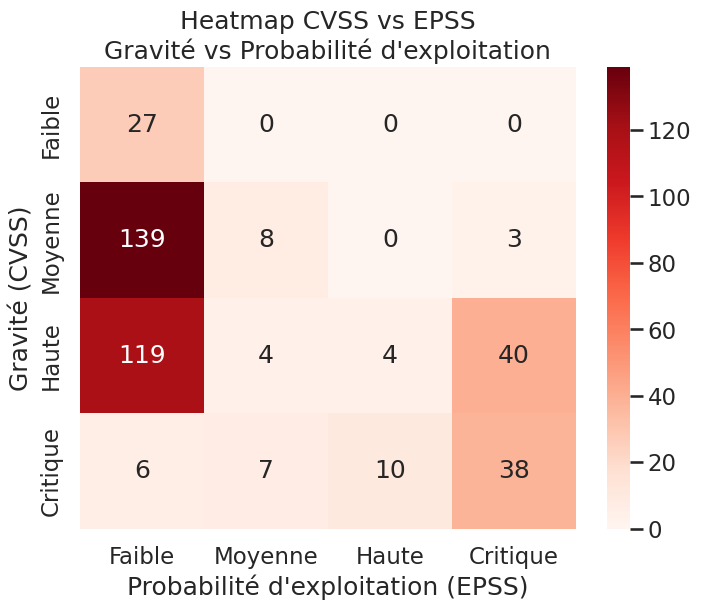

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copie propre
df_heat = df.copy()

# Conversion numérique
df_heat["Score CVSS"] = pd.to_numeric(df_heat["Score CVSS"], errors="coerce")
df_heat["Score EPSS"] = pd.to_numeric(df_heat["Score EPSS"], errors="coerce")

# Suppression des valeurs manquantes
df_heat = df_heat.dropna(subset=["Score CVSS", "Score EPSS"])

# Discrétisation (bins)
df_heat["CVSS_bin"] = pd.cut(
    df_heat["Score CVSS"],
    bins=[0, 4, 7, 9, 10],
    labels=["Faible", "Moyenne", "Haute", "Critique"]
)

df_heat["EPSS_bin"] = pd.cut(
    df_heat["Score EPSS"],
    bins=[0, 0.2, 0.5, 0.8, 1],
    labels=["Faible", "Moyenne", "Haute", "Critique"]
)

# Table de contingence
heatmap_data = pd.crosstab(df_heat["CVSS_bin"], df_heat["EPSS_bin"])

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Reds")
plt.title("Heatmap CVSS vs EPSS\nGravité vs Probabilité d'exploitation")
plt.xlabel("Probabilité d'exploitation (EPSS)")
plt.ylabel("Gravité (CVSS)")
plt.show()
